# IoT MQTT Authentication — Random Forest Pipeline

Third companion to `logistic_regression_pipeline.ipynb` and `decision_tree_pipeline.ipynb`.
Data loading, cleaning and the train/test split are **identical** to both, so the three
models are directly comparable; what changes is the learner and the analysis it invites.

A Random Forest is an ensemble of decision trees, each grown on a bootstrap resample of
the training set and each choosing its splits from a **random subset of features**. The
two sources of randomness are the point: bootstrapping decorrelates the trees' errors,
feature subsampling stops every tree from opening on the same dominant feature. Averaging
their votes cancels the variance that made the single tree of the previous notebook
fragile — without the pruning that tree needed.

That buys three things a single tree cannot give, and each has its own section here:

* **Free validation** — every tree leaves ~37% of rows out of its bootstrap sample, so the
  forest scores itself out-of-bag (§5.2) with no cross-validation.
* **Smooth probabilities** — a vote share over hundreds of trees, not a leaf frequency, so
  the ROC curve is continuous and the decision threshold is tunable (§6.3).
* **Honest importances** — with no single readable tree, interpretation moves to
  permutation importance measured on held-out data (§7).

The cost is the tree's headline advantage: there is no rule set to hand an analyst.

## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, GridSearchCV, cross_val_score, validation_curve,
)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    average_precision_score, precision_recall_curve, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay,
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 130)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Categorical dtype selector that behaves the same on pandas 2 (object) and 3 (str).
STR_DTYPES = ["object", "string"]

## 1. Data Loading

Load the per-session feature table produced by the simulator (same file as the
Logistic Regression and Decision Tree notebooks).

In [2]:
def find_features_csv():
    names = ["iot_auth_ml_features.csv", "iot_auth_dataset_features.csv"]
    bases = [Path.cwd(), *Path.cwd().parents]
    for base in bases:
        for sub in ["simulator/data/output", "IoT_auth_simulator/simulator/data/output"]:
            for n in names:
                p = base / sub / n
                if p.exists():
                    return p
    raise FileNotFoundError("Could not locate a *_features.csv under simulator/data/output/")

DATA_PATH = find_features_csv()
df = pd.read_csv(DATA_PATH)
print("Loaded:", DATA_PATH)
print("Shape :", df.shape)
df.head(3)

Loaded: C:\Users\lamia\Desktop\simulator_bis\PFE_simulator\IoT_auth_simulator\simulator\data\output\iot_auth_ml_features.csv
Shape : (3100, 109)


,scenario_id,session_id,device_id,gateway_id,claimed_device_id,source_ip,registered_device,source_connection_count,battery_level,tcp_flags,connection_duration,tcp_rtt,packet_rate,inter_arrival_time,frame_length,tcp_segment_len,pairing_result,pairing_latency_ms,mqtt_msg_type,connect_flags,clean_session,username_present,password_length,keep_alive,mqtt_version,connack_code,auth_result,auth_latency_ms,failed_auth_count,requested_topic,topic_length,operation,authorization_result,topic_scope_violation,retain_flag,message_id,duplicate_flag,payload_length,payload_hash,qos_level,message_rate,byte_rate,trust_score,re_auth_required,session_present,source_ip_change,replay_window_violation,s1_latency_ms,s2_latency_ms,s3_latency_ms,s4_latency_ms,s5_latency_ms,s6_latency_ms,session_duration_s,mean_delay_s,max_delay_s,min_delay_s,n_events,n_discovery,n_gateway_advertisement,n_pairing_request,n_pairing_response,n_enrollment_request,n_enrollment_confirmed,n_registration_request,n_registration_confirmed,n_authentication_request,n_challenge_sent,n_nonce_received,n_response_sent,n_authentication_success,n_authentication_failure,n_token_issued,n_token_presented,n_token_validated,n_token_rejected,n_renewal_request,n_token_expired,n_session_opened,n_session_closed,n_access_request,n_access_granted,n_access_denied,n_retry,n_timeout,n_disconnect,visited_states,reached_session_open,reached_access_granted,reached_authenticated,n_failures,n_retries,failure_rate,n_token_reuses,n_nonce_reuses,identity_mismatch,n_state_jumps,is_anomaly,attack_type,attack_phase,severity,token_age_at_replay,nonce_age_at_reuse,timestamp_delta_s,duplicate_session_count,identity_claim_mismatch,token_device_mismatch,unauthorized_access_attempt,steps_before_access
0,adaa4614-7cfb-4d92-a48d-40f1873c205a,b49a5e1d-a25e-40d1-9fc7-df1153c59b83,c65a1b9d-d3b2-4b66-84ef-df70b1c8d200,6727f600,victim-807e3635,10.0.1.194,0,6,49.1,"SYN,ACK",837.99,34.13,1.952,512.30,139,442,1,223.63,PUBLISH,0,0,0,0,120,5,pending,0,0.00,0,iot/c65a1b9d/telemetry,22,publish,0,0,0,62086,0,507,72cae37a12c268fe6049b9fb6a017259e0d2dc0e67813d...,2,0.211,106.98,0.300,0,0,0,0,0.0,0.00,0.00,0.00,0.00,0.0,0.8380,0.1197,0.2236,0.0487,7,1,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,6,0,0,1,1,0,0.1429,0,0,1,1,1,identity_token_mismatch,session_opened,high,0.0,0.0,0.0,0,1,1,0,0
1,6ac08da2-5a77-4d3a-88ac-4bb963ab6dd3,033e3fce-04e8-4cc7-b944-4ee69a00d935,7c996c3f-9cb4-45e1-8865-d189fd910b31,088e9971,7c996c3f-9cb4-45e1-8865-d189fd910b31,10.0.1.187,1,9,98.5,"SYN,ACK,PSH",20405.25,13.78,45.757,21.85,242,370,1,42.39,DISCONNECT,0,0,0,0,300,5,success,1,30.69,0,iot/7c996c3f/telemetry,22,pub_sub,1,0,0,61867,0,0,NaN,0,12.059,5342.14,0.890,0,1,0,0,0.0,77.37,30.69,72.55,63.66,0.0,20.4052,1.0203,16.1885,0.0307,20,1,1,1,1,1,1,0,0,1,1,1,1,1,0,1,1,1,0,0,0,1,1,1,1,1,1,0,0,16,1,1,1,2,0,0.1000,6,2,0,0,0,normal,none,none,0.0,0.0,0.0,0,0,0,0,0
2,907d754c-b876-41ff-b22d-6963f6eeaaba,4a8e748f-ba0a-4672-9849-1a92edc1ded9,7e34ef06-604f-438a-add6-7a2603b5cc7a,a7db51e6,7e34ef06-604f-438a-add6-7a2603b5cc7a,10.0.1.30,1,7,57.9,"SYN,ACK",86802.69,19.33,28.486,35.10,76,283,1,290.44,UNSUBSCRIBE,0,0,0,0,300,5,success,1,30.71,0,iot/7e34ef06/telemetry,22,pub_sub,1,0,0,56067,0,0,NaN,1,8.980,951.88,0.776,0,1,0,0,0.0,104.65,30.71,76.33,52.67,0.0,86.8027,3.6168,76.7943,0.0307,24,1,1,1,1,1,1,0,0,1,1,1,1,1,0,1,1,1,0,0,0,1,1,3,3,1,1,0,0,16,1,1,1,1,0,0.0417,10,2,0,0,0,normal,none,none,0.0,0.0,0.0,0,0,0,0,0


## 2. Data Understanding (EDA)

Condensed here — the full exploration lives in `iot_auth_features_analysis.ipynb`. What
matters for the forest is the class balance (which sets the scoring metric) and the
structural-separability check below (which sets how much to trust the score).

In [3]:
print("Rows x Cols:", df.shape)
print("\nDtype counts:")
print(df.dtypes.value_counts())

print("\nBinary target - is_anomaly (proportion):")
print(df["is_anomaly"].value_counts(normalize=True).round(3).rename({0: "normal", 1: "anomaly"}))

print("\nMulticlass target - attack_type (counts):")
print(df["attack_type"].value_counts())

Rows x Cols: (3100, 109)

Dtype counts:
int64      70
float64    24
str        15
Name: count, dtype: int64

Binary target - is_anomaly (proportion):
is_anomaly
normal     0.645
anomaly    0.355
Name: proportion, dtype: float64

Multiclass target - attack_type (counts):
attack_type
normal                     2000
identity_token_mismatch     132
nonce_reuse                 132
access_without_auth         132
replay_token                132
impersonation               132
timestamp_inconsistency     132
duplicate_sequence          121
abnormal_failure_rate        99
abnormal_renewal             88
Name: count, dtype: int64


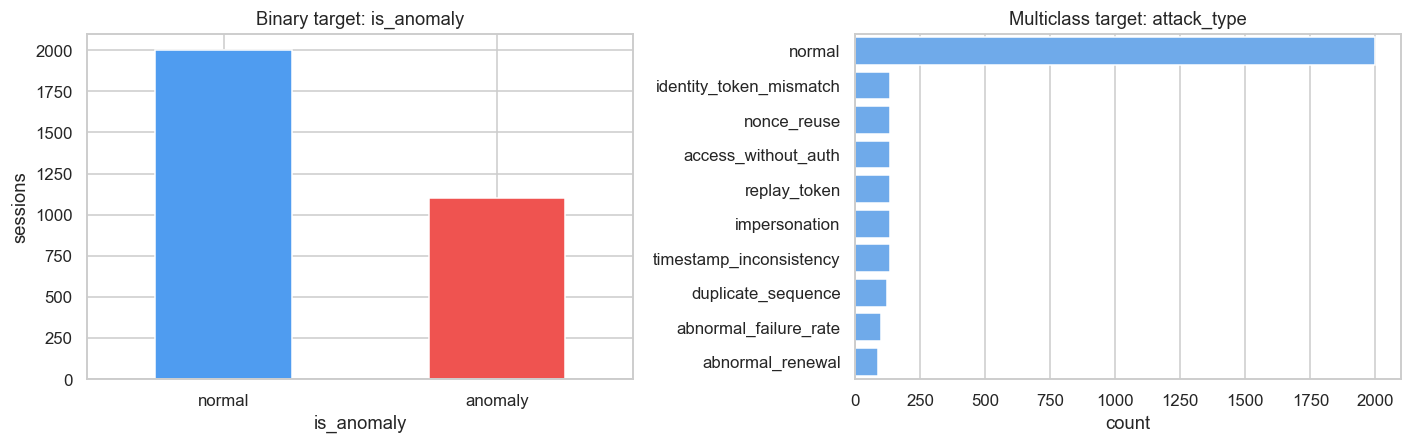

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
(df["is_anomaly"].map({0: "normal", 1: "anomaly"}).value_counts()
   .plot.bar(ax=axes[0], color=["#4f9cf0", "#ef5350"], rot=0))
axes[0].set_title("Binary target: is_anomaly"); axes[0].set_ylabel("sessions")

order = df["attack_type"].value_counts().index
sns.countplot(data=df, y="attack_type", order=order, ax=axes[1], color="#5aa9ff")
axes[1].set_title("Multiclass target: attack_type"); axes[1].set_ylabel("")
plt.tight_layout(); plt.show()

In [5]:
# Missingness
miss = df.isna().mean().sort_values(ascending=False)
print("Columns with any missing values:", int((miss > 0).sum()))
miss[miss > 0].head(15)

Columns with any missing values: 1


payload_hash    0.676129
dtype: float64

### Structural-separability check

An **earlier** version of this dataset leaked the label structurally: attacks terminated
the session at the injection point, so they were much shorter than normal sessions and
length / lifecycle features (`n_events`, `session_duration_s`, `reached_*`,
`visited_states`, …) separated the classes almost perfectly on their own — independently
of any authentication signal.

The generator has since been **fixed**: attacks run the full authentication lifecycle, a
tunable *stealth* fraction of them is deliberately indistinguishable from normal traffic,
and durations are computed on a monotonic clock. The companion
`iot_auth_features_analysis.ipynb` now flags **zero** features at single-feature
separability AUC ≥ 0.90. The boxplots below show the residual difference is mild and the
distributions overlap; §8 re-checks it at model level.

This check matters more for a forest than for the two earlier models. An ensemble is very
good at squeezing a weak shortcut out of many correlated features — exactly the failure
mode that would look like a great score and generalise to nothing.

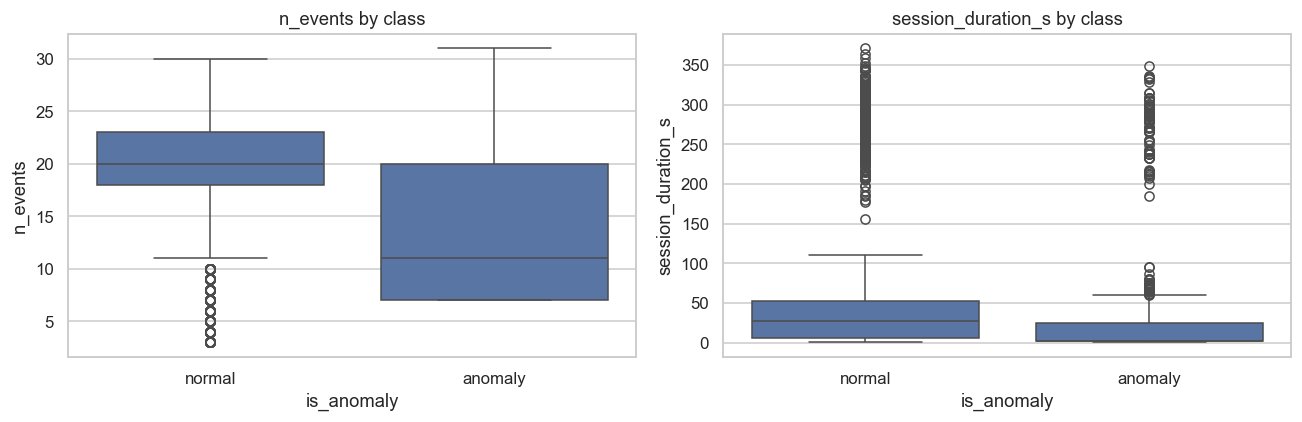

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=df, x="is_anomaly", y="n_events", ax=axes[0])
axes[0].set_xticks([0, 1]); axes[0].set_xticklabels(["normal", "anomaly"])
axes[0].set_title("n_events by class")
sns.boxplot(data=df, x="is_anomaly", y="session_duration_s", ax=axes[1])
axes[1].set_xticks([0, 1]); axes[1].set_xticklabels(["normal", "anomaly"])
axes[1].set_title("session_duration_s by class")
plt.tight_layout(); plt.show()

## 3. Data Cleaning

Identical to the Logistic Regression and Decision Tree notebooks — deliberately, so any
score difference between the three comes from the learner, not from the features.

* **Identifiers** — UUIDs / IPs / topics with no predictive value and infinite cardinality.
* **Label aliases** — `attack_type`, `attack_phase`, `severity` (and `attacker_class` when
  present) all encode the target and would leak it directly.
* **Constant columns** — zero-variance features (event counts for events that never fire
  in a nominal flow) carry no information.

Missing values are then imputed (`0` for numerics, `"missing"` for categoricals).

In [7]:
TARGET = "is_anomaly"

ID_COLS = ["scenario_id", "session_id", "device_id", "gateway_id",
           "claimed_device_id", "source_ip", "requested_topic",
           "payload_hash", "message_id"]
LABEL_ALIASES = ["attack_type", "attack_phase", "severity", "attacker_class"]

const_cols = [c for c in df.columns if df[c].nunique(dropna=False) <= 1]
print("Constant columns dropped (", len(const_cols), "):", const_cols)

drop_cols = sorted((set(ID_COLS) | set(LABEL_ALIASES) | set(const_cols)) & set(df.columns))
X = df.drop(columns=drop_cols + [TARGET])
y = df[TARGET].astype(int)

cat_cols = X.select_dtypes(include=STR_DTYPES).columns.tolist()
num_cols = X.select_dtypes(exclude=STR_DTYPES).columns.tolist()
X[cat_cols] = X[cat_cols].fillna("missing")
X[num_cols] = X[num_cols].fillna(0)

print(f"\nFeatures kept: {X.shape[1]}  ({len(num_cols)} numeric, {len(cat_cols)} categorical)")
print("Categorical:", cat_cols)

Constant columns dropped ( 11 ): ['mqtt_version', 'topic_length', 'duplicate_flag', 's1_latency_ms', 'n_gateway_advertisement', 'n_pairing_request', 'n_registration_request', 'n_registration_confirmed', 'n_token_rejected', 'n_token_expired', 'n_timeout']

Features kept: 85  (81 numeric, 4 categorical)
Categorical: ['tcp_flags', 'mqtt_msg_type', 'connack_code', 'operation']


## 4. Preprocessing & Train/Test Split

Same as the Decision Tree notebook: a forest is a collection of trees, and a tree splits on
thresholds *within* one feature at a time, so it is invariant to monotone rescaling.
**No `StandardScaler`** — numeric columns pass through in their physical units, which keeps
split thresholds readable (`token_age_at_replay > 41.6 s`, not `> 0.83 σ`).

Categoricals are one-hot encoded. All four are low-cardinality, so this adds few columns;
worth noting because impurity-based importances are biased toward high-cardinality and
continuous features, which is one reason §7 does not stop at them.

Stratified 80/20 split, same `random_state` as the other two notebooks.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)

preprocess = ColumnTransformer([
    ("num", "passthrough", num_cols),                                   # trees need no scaling
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
])
print("Train:", X_train.shape, " Test:", X_test.shape)
print("Train class balance:", np.bincount(y_train), " Test class balance:", np.bincount(y_test))
print("Encoded feature count:", preprocess.fit(X_train).transform(X_train[:1]).shape[1])

Train: (2480, 85)  Test: (620, 85)
Train class balance: [1600  880]  Test class balance: [400 220]
Encoded feature count: 102


## 5. Model Training — Random Forest

### 5.1 Baseline: what averaging buys

The previous notebook showed a fully-grown single tree memorising the training set —
training F1 of 1.0 and a wide gap to the test score — which is why it needed pruning.

Here the **same** unconstrained tree is put next to an unconstrained forest of 300 such
trees. The individual trees still memorise (their training F1 is still ~1.0); the forest's
*test* score is nonetheless higher and the gap narrower. Nothing was pruned. Averaging over
bootstrap resamples cancels the part of each tree's error that comes from the particular
rows it saw — that is variance reduction, and it is the whole argument for the ensemble.

In [9]:
dt_full = Pipeline([
    ("pre", preprocess),
    ("dt", DecisionTreeClassifier(random_state=RANDOM_STATE)),
]).fit(X_train, y_train)

rf_base = Pipeline([
    ("pre", preprocess),
    ("rf", RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)),
]).fit(X_train, y_train)

def gap_row(model, label):
    tr = f1_score(y_train, model.predict(X_train))
    te = f1_score(y_test,  model.predict(X_test))
    return {"model": label, "train F1": tr, "test F1": te, "gap": tr - te,
            "test AUC": roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])}

baseline_cmp = pd.DataFrame([
    gap_row(dt_full, "single tree (unpruned)"),
    gap_row(rf_base, "forest, 300 trees (unpruned)"),
]).set_index("model")
display(baseline_cmp.round(4))

tree_depths = [e.get_depth() for e in rf_base.named_steps["rf"].estimators_]
print(f"Depth of the 300 trees in the forest: min {min(tree_depths)}, "
      f"median {int(np.median(tree_depths))}, max {max(tree_depths)} "
      f"(single tree: {dt_full.named_steps['dt'].get_depth()})")

,train F1,test F1,gap,test AUC
model,,,,
single tree (unpruned),1.0,0.9070,0.0930,0.9283
"forest, 300 trees (unpruned)",1.0,0.9423,0.0577,0.9758


Depth of the 300 trees in the forest: min 16, median 22, max 31 (single tree: 29)


### 5.2 Out-of-bag error — validation for free

Each tree is fitted on a bootstrap resample of the training set. Sampling *n* rows with
replacement leaves about $(1 - 1/n)^n \to 1/e \approx 37\%$ of rows unused by that tree.
Those rows are **out-of-bag** for it: unseen, and therefore usable as a test set for that
one tree. Aggregating each row's votes over only the trees that did not see it gives the
OOB score — an unbiased generalisation estimate obtained during fitting, with no separate
validation fold and no refits.

The curve below refits incrementally (`warm_start=True`) to show OOB error against forest
size, which answers the practical question: **how many trees are enough?** The error falls
steeply, then flattens. Past the plateau, extra trees cost time and buy nothing — more
trees never *overfit* a forest, they just stop helping.

The second cell checks the free estimate against a real 5-fold CV.

c:\Users\lamia\Desktop\simulator_bis\.venv\Lib\site-packages\sklearn\ensemble\_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


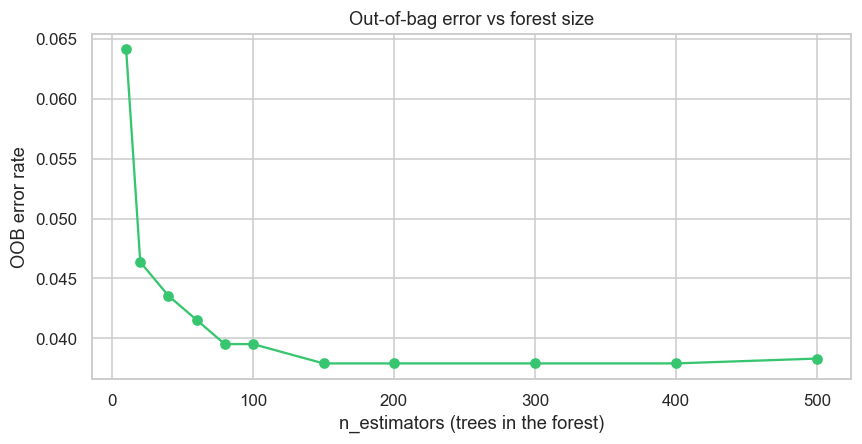

OOB error by forest size:
    10 trees   0.0641
    20 trees   0.0464
    40 trees   0.0435
    60 trees   0.0415
    80 trees   0.0395
   100 trees   0.0395
   150 trees   0.0379
   200 trees   0.0379
   300 trees   0.0379
   400 trees   0.0379
   500 trees   0.0383

Plateau reached around 150 trees (min OOB error 0.0379).


In [10]:
oob_grid = [10, 20, 40, 60, 80, 100, 150, 200, 300, 400, 500]
rf_oob = RandomForestClassifier(warm_start=True, oob_score=True, bootstrap=True,
                                random_state=RANDOM_STATE, n_jobs=-1)

enc = preprocess.fit(X_train)                 # encode once; warm_start refits in place
Xtr_enc, Xte_enc = enc.transform(X_train), enc.transform(X_test)
feat_names = enc.get_feature_names_out()

oob_err = []
for n in oob_grid:
    rf_oob.set_params(n_estimators=n)
    rf_oob.fit(Xtr_enc, y_train)
    oob_err.append(1 - rf_oob.oob_score_)

plt.figure(figsize=(8, 4.2))
plt.plot(oob_grid, oob_err, "o-", color="#37c66f")
plt.xlabel("n_estimators (trees in the forest)"); plt.ylabel("OOB error rate")
plt.title("Out-of-bag error vs forest size")
plt.tight_layout(); plt.show()

print("OOB error by forest size:")
for n, e in zip(oob_grid, oob_err):
    print(f"  {n:>4} trees   {e:.4f}")
print(f"\nPlateau reached around {oob_grid[int(np.argmin(oob_err))]} trees "
      f"(min OOB error {min(oob_err):.4f}).")

In [11]:
# Is the free OOB estimate trustworthy? Compare against honest 5-fold CV.
rf_check = Pipeline([("pre", preprocess),
                     ("rf", RandomForestClassifier(n_estimators=300, oob_score=True,
                                                   random_state=RANDOM_STATE, n_jobs=-1))]).fit(X_train, y_train)
cv_acc = cross_val_score(
    Pipeline([("pre", preprocess),
              ("rf", RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1))]),
    X_train, y_train, cv=CV, scoring="accuracy", n_jobs=-1)

print(f"OOB accuracy          : {rf_check.named_steps['rf'].oob_score_:.4f}   (free, from the bootstrap)")
print(f"5-fold CV accuracy    : {cv_acc.mean():.4f} +/- {cv_acc.std():.4f}   (5 extra refits)")
print(f"Difference            : {abs(rf_check.named_steps['rf'].oob_score_ - cv_acc.mean()):.4f}")

OOB accuracy          : 0.9621   (free, from the bootstrap)
5-fold CV accuracy    : 0.9617 +/- 0.0084   (5 extra refits)
Difference            : 0.0004


### 5.3 `max_features` — the knob that makes it a *forest*

Bootstrapping alone (that is, bagging) is not enough. If a handful of features are strongly
predictive, every tree opens on the same one, the trees end up highly correlated, and
averaging correlated errors removes little variance. Random Forest adds the second source of
randomness: at **each split**, only a random subset of `max_features` candidates is
considered.

Small `max_features` → more decorrelated, individually weaker trees. Large `max_features` →
stronger but more similar trees; at `max_features=None` the forest degenerates into plain
bagging. The validation curve locates the trade-off on this dataset.

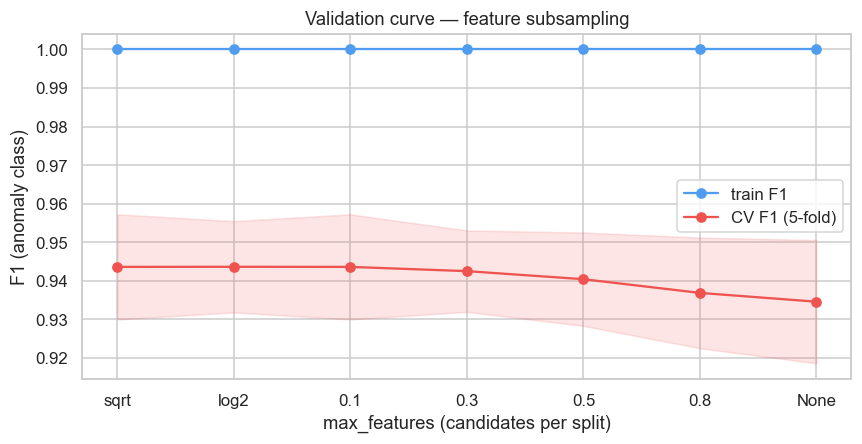

Best max_features by CV F1: log2  (CV F1 = 0.9437)
Plain bagging (max_features=None): CV F1 = 0.9346


In [12]:
mf_range = ["sqrt", "log2", 0.1, 0.3, 0.5, 0.8, None]
mf_labels = [str(m) for m in mf_range]

train_sc, val_sc = validation_curve(
    Pipeline([("pre", preprocess),
              ("rf", RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1))]),
    X_train, y_train, param_name="rf__max_features", param_range=mf_range,
    cv=CV, scoring="f1", n_jobs=-1)

xs = np.arange(len(mf_range))
plt.figure(figsize=(8, 4.2))
plt.plot(xs, train_sc.mean(1), "o-", color="#4f9cf0", label="train F1")
plt.plot(xs, val_sc.mean(1),   "o-", color="#ef5350", label="CV F1 (5-fold)")
plt.fill_between(xs, val_sc.mean(1) - val_sc.std(1), val_sc.mean(1) + val_sc.std(1),
                 color="#ef5350", alpha=0.15)
plt.xticks(xs, mf_labels); plt.xlabel("max_features (candidates per split)")
plt.ylabel("F1 (anomaly class)")
plt.title("Validation curve — feature subsampling")
plt.legend(); plt.tight_layout(); plt.show()

best_mf = mf_range[int(np.argmax(val_sc.mean(1)))]
print(f"Best max_features by CV F1: {best_mf}  (CV F1 = {val_sc.mean(1).max():.4f})")
print(f"Plain bagging (max_features=None): CV F1 = {val_sc.mean(1)[-1]:.4f}")

### 5.4 Grid search

Search `max_features` x `max_depth` x `min_samples_leaf` x `class_weight`, scored on
**anomaly-class F1** (not accuracy — with 35% attacks, accuracy is still the wrong headline
metric) with 5-fold CV on the training set. The test set stays untouched until §6.

`n_estimators` is deliberately *not* in the grid: §5.2 showed the OOB error plateaus, so
tree count is a compute/latency decision rather than an accuracy one. The search runs at 200
trees for speed, and the winner is refit at 500.

`class_weight="balanced_subsample"` is the forest-specific variant of `"balanced"`: weights
are recomputed per bootstrap sample rather than once on the full training set.

In [13]:
param_grid = {
    "rf__max_features":     ["sqrt", "log2", 0.3],
    "rf__max_depth":        [None, 8, 16],
    "rf__min_samples_leaf": [1, 2, 5],
    "rf__class_weight":     [None, "balanced_subsample"],
}

gs = GridSearchCV(
    Pipeline([("pre", preprocess),
              ("rf", RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1))]),
    param_grid, scoring="f1", cv=CV, n_jobs=-1, refit=False)
gs.fit(X_train, y_train)

print("Best CV F1 (anomaly):", round(gs.best_score_, 4))
for k, v in gs.best_params_.items():
    print(f"  {k:24s} {v}")

best_rf_params = {k.replace("rf__", ""): v for k, v in gs.best_params_.items()}
rf_clf = Pipeline([
    ("pre", preprocess),
    ("rf", RandomForestClassifier(n_estimators=500, oob_score=True, random_state=RANDOM_STATE,
                                  n_jobs=-1, **best_rf_params)),
]).fit(X_train, y_train)
forest_ = rf_clf.named_steps["rf"]
print(f"\nRefit at 500 trees — OOB accuracy {forest_.oob_score_:.4f}")

Best CV F1 (anomaly): 0.9437
  rf__class_weight         None
  rf__max_depth            None
  rf__max_features         log2
  rf__min_samples_leaf     1



Refit at 500 trees — OOB accuracy 0.9617


In [14]:
# Top-10 grid-search configurations
cvres = (pd.DataFrame(gs.cv_results_)
           .sort_values("rank_test_score")
           .loc[:, ["param_rf__max_features", "param_rf__max_depth",
                    "param_rf__min_samples_leaf", "param_rf__class_weight",
                    "mean_test_score", "std_test_score", "mean_fit_time"]]
           .head(10)
           .rename(columns=lambda c: c.replace("param_rf__", "")))
cvres.round(4)

,max_features,max_depth,min_samples_leaf,class_weight,mean_test_score,std_test_score,mean_fit_time
3,log2,None,1,NaN,0.9437,0.0118,3.0778
25,0.3,16,2,NaN,0.9436,0.0133,6.6828
0,sqrt,None,1,NaN,0.9436,0.0136,1.7587
24,0.3,16,1,NaN,0.9431,0.0121,5.7590
30,log2,None,1,balanced_subsample,0.9429,0.0123,6.7530
21,log2,16,1,NaN,0.9429,0.0123,3.5717
6,0.3,None,1,NaN,0.9425,0.0106,3.2665
22,log2,16,2,NaN,0.9425,0.0130,3.8424
18,sqrt,16,1,NaN,0.9425,0.0123,3.6446
7,0.3,None,2,NaN,0.9424,0.0130,4.0448


## 6. Evaluation

Reported on the **anomaly class**, not the weighted average: with 65% normals the weighted
F1 flatters the model and hides exactly the misses that matter (the deliberately-stealthy
attacks).

In [15]:
y_pred  = rf_clf.predict(X_test)
y_proba = rf_clf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=["normal", "anomaly"], digits=4))
print("Accuracy            :", round(accuracy_score(y_test, y_pred), 4))
print("Precision (anomaly) :", round(precision_score(y_test, y_pred), 4))
print("Recall    (anomaly) :", round(recall_score(y_test, y_pred), 4))
print("F1        (anomaly) :", round(f1_score(y_test, y_pred), 4))
print("ROC-AUC             :", round(roc_auc_score(y_test, y_proba), 4))
print("Average precision   :", round(average_precision_score(y_test, y_proba), 4))

              precision    recall  f1-score   support

      normal     0.9433    0.9975    0.9696       400
     anomaly     0.9949    0.8909    0.9400       220

    accuracy                         0.9597       620
   macro avg     0.9691    0.9442    0.9548       620
weighted avg     0.9616    0.9597    0.9591       620

Accuracy            : 0.9597
Precision (anomaly) : 0.9949
Recall    (anomaly) : 0.8909
F1        (anomaly) : 0.94
ROC-AUC             : 0.9748
Average precision   : 0.9707


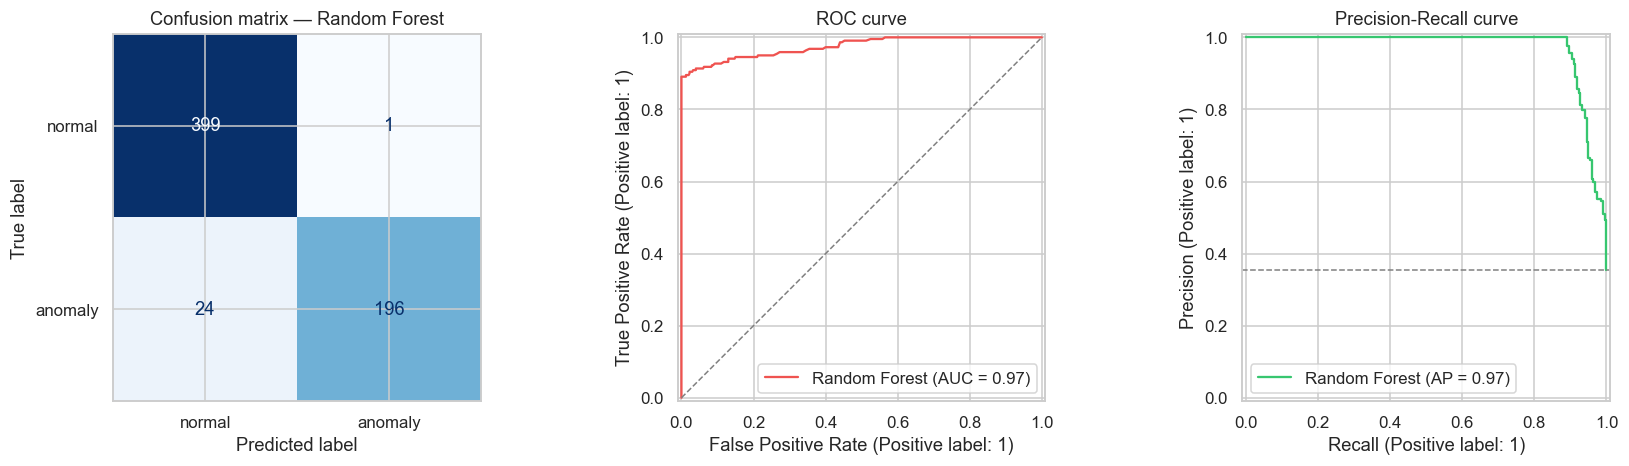

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=["normal", "anomaly"], cmap="Blues", ax=axes[0], colorbar=False)
axes[0].set_title("Confusion matrix — Random Forest")

RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1], name="Random Forest",
                                 curve_kwargs={"color": "#ef5350"})
axes[1].plot([0, 1], [0, 1], "--", color="grey", lw=1)
axes[1].set_title("ROC curve")

PrecisionRecallDisplay.from_predictions(y_test, y_proba, ax=axes[2], name="Random Forest",
                                        color="#37c66f")
axes[2].axhline(y_test.mean(), ls="--", color="grey", lw=1)
axes[2].set_title("Precision-Recall curve")
plt.tight_layout(); plt.show()

### 6.2 Where the misses are

The false negatives are the operationally interesting cell of the matrix: sessions that were
attacks and passed. Broken down by `attack_type`, they should concentrate in the stealth
families the generator deliberately made indistinguishable — if they were spread evenly, or
concentrated in a loud attack, that would point at a modelling failure rather than a data
design choice.

False negatives: 24 of 220 attacks   |   False positives: 1 of 400 normals



,attacks,missed,recall
attack_type,,,
replay_token,27,6,0.778
timestamp_inconsistency,32,7,0.781
nonce_reuse,23,4,0.826
impersonation,32,4,0.875
identity_token_mismatch,23,2,0.913
abnormal_renewal,19,1,0.947
abnormal_failure_rate,18,0,1.000
duplicate_sequence,25,0,1.000
access_without_auth,21,0,1.000


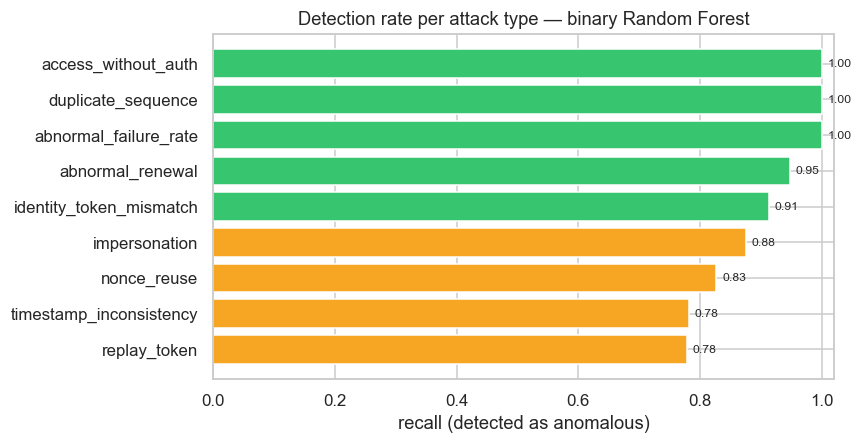

In [17]:
miss_df = pd.DataFrame({
    "attack_type": df.loc[X_test.index, "attack_type"].values,
    "true": y_test.values, "pred": y_pred, "proba": y_proba,
})
fn = miss_df[(miss_df["true"] == 1) & (miss_df["pred"] == 0)]
fp = miss_df[(miss_df["true"] == 0) & (miss_df["pred"] == 1)]

print(f"False negatives: {len(fn)} of {int(y_test.sum())} attacks   |   "
      f"False positives: {len(fp)} of {int((y_test == 0).sum())} normals\n")

per_type = (miss_df[miss_df["true"] == 1]
            .groupby("attack_type")
            .agg(attacks=("true", "size"), missed=("pred", lambda s: int((s == 0).sum())))
            .assign(recall=lambda d: 1 - d["missed"] / d["attacks"])
            .sort_values("recall"))
display(per_type.round(3))

plt.figure(figsize=(8, 4.2))
colors = ["#ef5350" if v < 0.7 else "#f6a623" if v < 0.9 else "#37c66f" for v in per_type["recall"]]
plt.barh(per_type.index, per_type["recall"], color=colors)
plt.xlim(0, 1.02); plt.xlabel("recall (detected as anomalous)")
plt.title("Detection rate per attack type — binary Random Forest")
for i, v in enumerate(per_type["recall"]):
    plt.text(v + 0.01, i, f"{v:.2f}", va="center", fontsize=8)
plt.tight_layout(); plt.show()

### 6.3 Threshold tuning

A forest scores a session by the fraction of its 500 trees voting *anomaly*. That is a far
better-resolved number than a single tree's leaf frequency, so the 0.5 cut-off is a
convention, not a constraint — and in intrusion detection it is rarely the right one. Two
operating points are worth naming:

* the **F1-optimal** threshold, the best precision/recall balance;
* the **high-recall** point — the lowest threshold at which precision stays acceptable,
  for a deployment that would rather review false alarms than miss an intrusion.

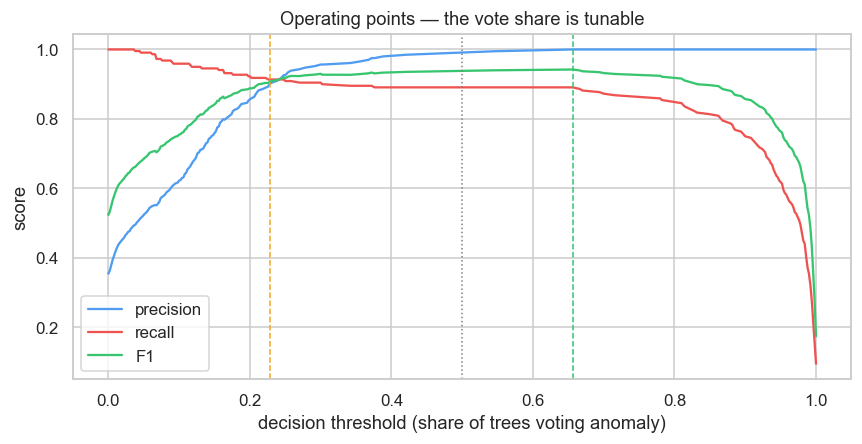

,threshold,precision,recall,F1,missed attacks,false alarms
operating point,,,,,,
default (0.5),0.500,0.9949,0.8909,0.9400,24,1
F1-optimal,0.656,1.0000,0.8909,0.9423,24,0
high-recall (prec>=0.9),0.228,0.9013,0.9136,0.9074,19,22


In [18]:
prec, rec, thr = precision_recall_curve(y_test, y_proba)
f1s = np.divide(2 * prec * rec, prec + rec, out=np.zeros_like(prec), where=(prec + rec) > 0)
best_i = int(np.argmax(f1s[:-1]))
best_thr = float(thr[best_i])

MIN_PREC = 0.90
ok = np.where(prec[:-1] >= MIN_PREC)[0]
hr_i = int(ok[np.argmax(rec[:-1][ok])]) if len(ok) else best_i
hr_thr = float(thr[hr_i])

plt.figure(figsize=(8, 4.2))
plt.plot(thr, prec[:-1], label="precision", color="#4f9cf0")
plt.plot(thr, rec[:-1],  label="recall",    color="#ef5350")
plt.plot(thr, f1s[:-1],  label="F1",        color="#37c66f")
plt.axvline(0.5, ls=":", color="grey", lw=1)
plt.axvline(best_thr, ls="--", color="#37c66f", lw=1)
plt.axvline(hr_thr,  ls="--", color="#f6a623", lw=1)
plt.xlabel("decision threshold (share of trees voting anomaly)"); plt.ylabel("score")
plt.title("Operating points — the vote share is tunable")
plt.legend(); plt.tight_layout(); plt.show()

rows = []
for name, t in [("default (0.5)", 0.5), ("F1-optimal", best_thr),
                (f"high-recall (prec>={MIN_PREC})", hr_thr)]:
    p = (y_proba >= t).astype(int)
    rows.append({"operating point": name, "threshold": t,
                 "precision": precision_score(y_test, p), "recall": recall_score(y_test, p),
                 "F1": f1_score(y_test, p),
                 "missed attacks": int(((y_test == 1) & (p == 0)).sum()),
                 "false alarms": int(((y_test == 0) & (p == 1)).sum())})
pd.DataFrame(rows).set_index("operating point").round(4)

## 7. Interpretation — importances, and which one to believe

A single tree *is* its explanation; 500 averaged trees are not. Interpretation therefore
shifts from reading rules to ranking features, and the ranking method matters.

**Impurity (Gini) importance** — the default `feature_importances_` — sums the impurity a
feature removes across all splits in all trees. It is free, but computed on *training* data
and structurally biased: it inflates continuous and high-cardinality features simply because
they offer more candidate split points, and it splits credit arbitrarily among correlated
features.

**Permutation importance** — shuffle one column in the *test* set, measure how much the
score drops — answers the question actually being asked: how much does the model's held-out
performance depend on this feature? It is the honest ranking, and the one to quote.

Both are computed below; where they disagree, the disagreement is itself the finding.

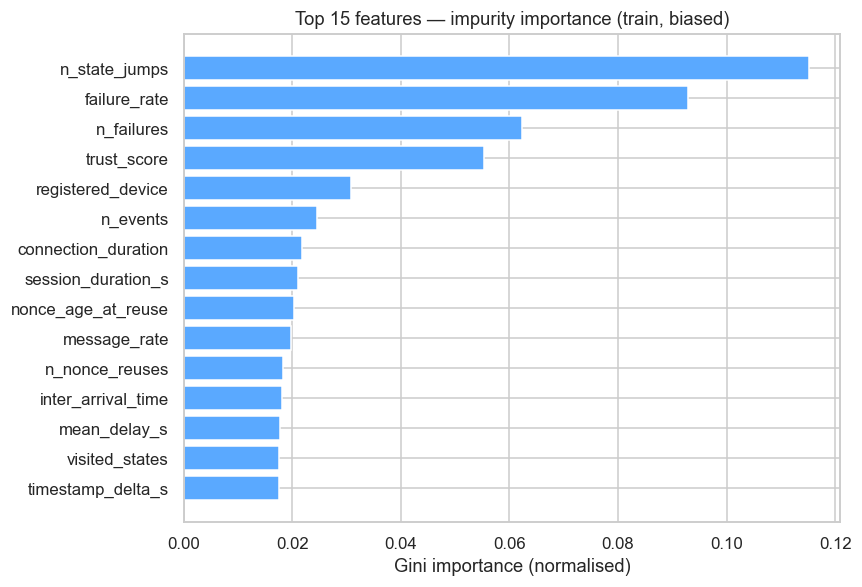

Features with non-zero impurity importance: 102 of 102
Top-10 share of total importance: 0.464


In [19]:
imp = (pd.Series(forest_.feature_importances_, index=feat_names)
         .sort_values(ascending=False))
top = imp.head(15)[::-1]

plt.figure(figsize=(8, 5.5))
plt.barh([n.replace("num__", "").replace("cat__", "") for n in top.index],
         top.values, color="#5aa9ff")
plt.xlabel("Gini importance (normalised)")
plt.title("Top 15 features — impurity importance (train, biased)")
plt.tight_layout(); plt.show()

print("Features with non-zero impurity importance:", int((imp > 0).sum()), "of", len(imp))
print("Top-10 share of total importance:", round(imp.head(10).sum(), 3))

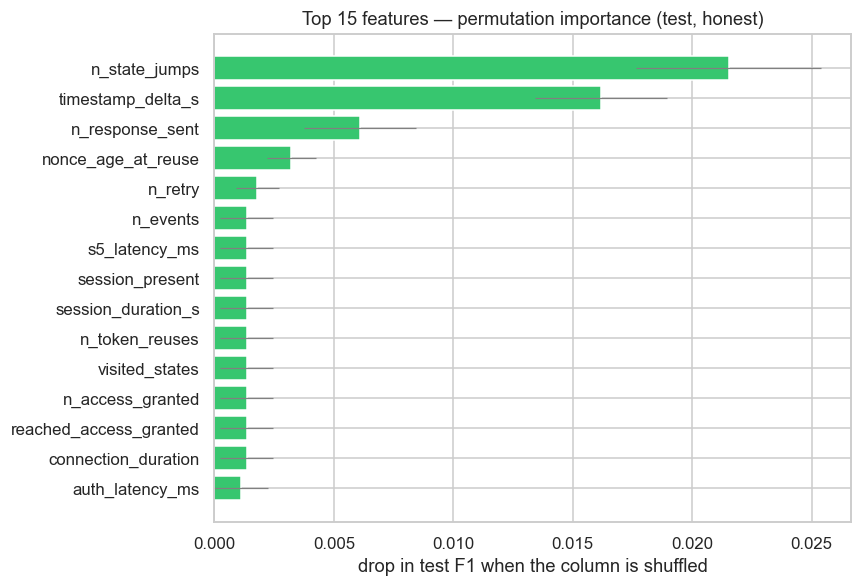

Features whose removal measurably hurts (mean drop > 0.001): 17 of 85


In [20]:
# Permutation importance on the held-out set, on the ORIGINAL columns
# (permuting a raw column moves all of its one-hot children together, which is what we want).
perm = permutation_importance(rf_clf, X_test, y_test, scoring="f1",
                              n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1)
perm_s = (pd.Series(perm.importances_mean, index=X_test.columns)
            .sort_values(ascending=False))
perm_sd = pd.Series(perm.importances_std, index=X_test.columns)

topp = perm_s.head(15)[::-1]
plt.figure(figsize=(8, 5.5))
plt.barh(topp.index, topp.values, xerr=perm_sd[topp.index].values,
         color="#37c66f", error_kw={"lw": 0.8, "ecolor": "grey"})
plt.xlabel("drop in test F1 when the column is shuffled")
plt.title("Top 15 features — permutation importance (test, honest)")
plt.tight_layout(); plt.show()

print("Features whose removal measurably hurts (mean drop > 0.001):",
      int((perm_s > 0.001).sum()), "of", len(perm_s))

In [21]:
# Where do the two rankings disagree?
imp_raw = (pd.Series(forest_.feature_importances_, index=feat_names)
             .rename(lambda n: n.replace("num__", "").replace("cat__", "").rsplit("_", 0)[0]))
imp_by_col = {c: imp_raw[[n for n in imp_raw.index if n == c or n.startswith(c + "_")]].sum()
              for c in X_test.columns}
cmp_imp = (pd.DataFrame({"impurity": pd.Series(imp_by_col), "permutation": perm_s})
             .assign(rank_impurity=lambda d: d["impurity"].rank(ascending=False).astype(int),
                     rank_perm=lambda d: d["permutation"].rank(ascending=False).astype(int))
             .assign(rank_shift=lambda d: d["rank_impurity"] - d["rank_perm"]))

print("Top 12 by permutation importance, with their impurity rank:\n")
display(cmp_imp.sort_values("permutation", ascending=False)
        .head(12)[["impurity", "permutation", "rank_impurity", "rank_perm", "rank_shift"]].round(4))

print("\nLargest rank disagreements among features impurity ranks in its top 20:")
display(cmp_imp[cmp_imp["rank_impurity"] <= 20]
        .reindex(cmp_imp[cmp_imp["rank_impurity"] <= 20]["rank_shift"].abs()
                 .sort_values(ascending=False).index)
        .head(8)[["rank_impurity", "rank_perm", "rank_shift"]])

Top 12 by permutation importance, with their impurity rank:


,impurity,permutation,rank_impurity,rank_perm,rank_shift
n_state_jumps,0.1152,0.0215,1,1,0
timestamp_delta_s,0.0175,0.0162,15,2,13
n_response_sent,0.0122,0.0061,26,3,23
nonce_age_at_reuse,0.0204,0.0032,9,4,5
n_retry,0.0016,0.0018,73,5,68
n_events,0.0246,0.0013,6,10,-4
n_token_reuses,0.0134,0.0013,24,10,14
n_access_granted,0.0136,0.0013,23,10,13
reached_access_granted,0.0105,0.0013,30,10,20
session_present,0.0086,0.0013,38,10,28



Largest rank disagreements among features impurity ranks in its top 20:


,rank_impurity,rank_perm,rank_shift
n_failures,3,81,-78
message_rate,10,83,-73
inter_arrival_time,12,83,-71
byte_rate,18,85,-67
packet_rate,16,83,-67
n_nonce_reuses,11,55,-44
mean_delay_s,13,55,-42
max_delay_s,17,55,-38


A feature that impurity ranks highly but permutation ranks low was useful for *growing*
the trees and is redundant at *prediction* time — typically one of a correlated group,
where the forest can recover the same information from its siblings. The reverse case,
high permutation and low impurity, is a feature that fires rarely but decisively.

Note what this costs relative to the previous notebook: the Decision Tree could print the
literal rule that flagged a session, in physical units. The forest can rank the evidence
but cannot hand an analyst a policy to transcribe into the gateway. That is the trade the
ensemble makes for its accuracy and its stability.

## 8. Robustness check — drop structural features

Same check as §7 of the LR notebook and §8 of the DT notebook: retrain after removing the
session-length / lifecycle group, keeping only the semantic authentication features (token
freshness, nonce reuse, identity mismatch, per-anomaly signals, network / MQTT context).

This is the sharpest version of the test. An ensemble can assemble a weak shortcut out of
many individually-uninformative structural features, so if a residual structural leak
existed anywhere in this dataset, the forest is the model that would find and exploit it.
A small drop here means the detection rests on genuine authentication evidence.

In [22]:
STRUCTURAL_LEAK = [
    "n_events", "session_duration_s", "mean_delay_s", "max_delay_s", "min_delay_s",
    "visited_states", "reached_session_open", "reached_access_granted",
    "reached_authenticated", "n_state_jumps", "connection_duration",
] + [c for c in num_cols if c.startswith("n_") and c not in
     ("n_failures", "n_retries", "n_nonce_reuses", "n_token_reuses", "n_renewal_request")]

leak_drop = [c for c in STRUCTURAL_LEAK if c in X.columns]
X2 = X.drop(columns=leak_drop)
num2 = [c for c in num_cols if c in X2.columns]
cat2 = [c for c in cat_cols if c in X2.columns]

Xtr2, Xte2, ytr2, yte2 = train_test_split(
    X2, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)
pre2 = ColumnTransformer([
    ("num", "passthrough", num2),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat2),
])
rf2 = Pipeline([("pre", pre2),
                ("rf", RandomForestClassifier(n_estimators=500, random_state=RANDOM_STATE,
                                              n_jobs=-1, **best_rf_params))]).fit(Xtr2, ytr2)
p2 = rf2.predict(Xte2); pr2 = rf2.predict_proba(Xte2)[:, 1]

print(f"Dropped {len(leak_drop)} structural features, {X2.shape[1]} remain.\n")
print("                  full features   structure-free")
print(f"Accuracy       :     {accuracy_score(y_test, y_pred):.4f}          {accuracy_score(yte2, p2):.4f}")
print(f"F1  (anomaly)  :     {f1_score(y_test, y_pred):.4f}          {f1_score(yte2, p2):.4f}")
print(f"Precision      :     {precision_score(y_test, y_pred):.4f}          {precision_score(yte2, p2):.4f}")
print(f"Recall         :     {recall_score(y_test, y_pred):.4f}          {recall_score(yte2, p2):.4f}")
print(f"ROC-AUC        :     {roc_auc_score(y_test, y_proba):.4f}          {roc_auc_score(yte2, pr2):.4f}")

Dropped 33 structural features, 54 remain.

                  full features   structure-free
Accuracy       :     0.9597          0.9548
F1  (anomaly)  :     0.9400          0.9336
Precision      :     0.9949          0.9752
Recall         :     0.8909          0.8955
ROC-AUC        :     0.9748          0.9742


## 9. Multiclass extension — `attack_type`

The same pipeline, now naming the specific attack variant (9 attacks + `normal`). Like the
tree, a forest handles multiclass natively — no one-vs-rest wrapper — and the vote-averaging
matters more here: the rare attack types have ~90-130 sessions each, exactly the regime where
a single tree's splits are unstable.

Scored on **macro-F1** so the small classes count as much as `normal`.

In [23]:
ymc = df["attack_type"]
Xmc = df.drop(columns=[c for c in (ID_COLS + ["attack_type", "attack_phase",
              "severity", "attacker_class", "is_anomaly"] + const_cols) if c in df.columns])
cmc = Xmc.select_dtypes(include=STR_DTYPES).columns.tolist()
nmc = Xmc.select_dtypes(exclude=STR_DTYPES).columns.tolist()
Xmc[cmc] = Xmc[cmc].fillna("missing"); Xmc[nmc] = Xmc[nmc].fillna(0)

Xtr, Xte, ytr, yte = train_test_split(
    Xmc, ymc, test_size=0.20, stratify=ymc, random_state=RANDOM_STATE)
pre_mc = ColumnTransformer([
    ("num", "passthrough", nmc),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cmc),
])

gs_mc = GridSearchCV(
    Pipeline([("pre", pre_mc),
              ("rf", RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1))]),
    {"rf__max_features": ["sqrt", 0.3],
     "rf__max_depth": [None, 16],
     "rf__min_samples_leaf": [1, 2],
     "rf__class_weight": [None, "balanced_subsample"]},
    scoring="f1_macro", cv=CV, n_jobs=-1).fit(Xtr, ytr)

rf_mc = gs_mc.best_estimator_
pmc = rf_mc.predict(Xte)
proba_mc = rf_mc.predict_proba(Xte)

print("Best params:", {k.replace("rf__", ""): v for k, v in gs_mc.best_params_.items()})
print("Best CV macro-F1:", round(gs_mc.best_score_, 4), "\n")
print(classification_report(yte, pmc, digits=3))
print("Macro one-vs-rest ROC-AUC:",
      round(roc_auc_score(yte, proba_mc, multi_class="ovr", average="macro",
                          labels=rf_mc.classes_), 4))

Best params: {'class_weight': None, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1}
Best CV macro-F1: 0.9531 

                         precision    recall  f1-score   support

  abnormal_failure_rate      1.000     0.950     0.974        20
       abnormal_renewal      1.000     0.778     0.875        18
    access_without_auth      1.000     1.000     1.000        26
     duplicate_sequence      1.000     0.833     0.909        24
identity_token_mismatch      1.000     0.962     0.980        26
          impersonation      1.000     0.885     0.939        26
            nonce_reuse      1.000     0.815     0.898        27
                 normal      0.920     1.000     0.958       400
           replay_token      1.000     0.667     0.800        27
timestamp_inconsistency      1.000     0.692     0.818        26

               accuracy                          0.944       620
              macro avg      0.992     0.858     0.915       620
           weighted avg 

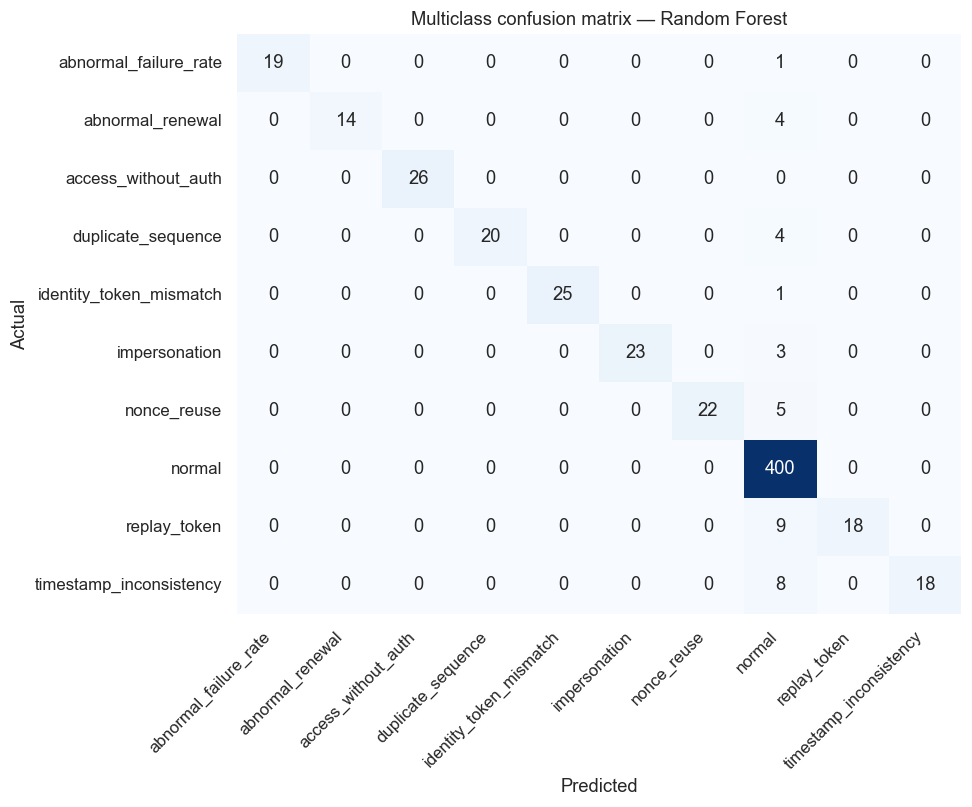

In [24]:
cm = confusion_matrix(yte, pmc, labels=rf_mc.classes_)
plt.figure(figsize=(9, 7.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=rf_mc.classes_, yticklabels=rf_mc.classes_, cbar=False)
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title("Multiclass confusion matrix — Random Forest")
plt.xticks(rotation=45, ha="right"); plt.yticks(rotation=0)
plt.tight_layout(); plt.show()

Per-attack recall is the honest picture of *which* attacks the forest can name. Read the
confusion matrix by row: misses that land in the `normal` column are missed intrusions,
while misses that land on another attack type were still detected — the alarm fired, only
the label was wrong. The second kind is far less costly operationally.

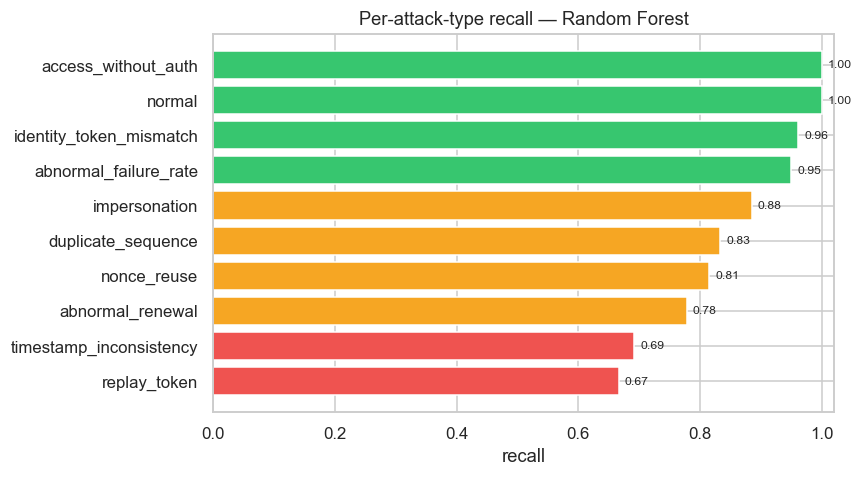

Attack sessions in test      : 220
  correctly named            : 185
  detected but mislabelled   : 0   (alarm still fires)
  missed as normal           : 35   (silent failure)


In [25]:
rec_rf = pd.Series({c: recall_score(yte == c, pmc == c) for c in rf_mc.classes_}).sort_values()
plt.figure(figsize=(8, 4.5))
colors = ["#ef5350" if v < 0.7 else "#f6a623" if v < 0.9 else "#37c66f" for v in rec_rf.values]
plt.barh(rec_rf.index, rec_rf.values, color=colors)
plt.xlim(0, 1.02); plt.xlabel("recall")
plt.title("Per-attack-type recall — Random Forest")
for i, v in enumerate(rec_rf.values):
    plt.text(v + 0.01, i, f"{v:.2f}", va="center", fontsize=8)
plt.tight_layout(); plt.show()

# How many multiclass errors were still caught as "some attack"?
attack_rows = yte != "normal"
missed_entirely = ((pmc == "normal") & attack_rows).sum()
mislabelled     = ((pmc != "normal") & attack_rows & (pmc != yte)).sum()
print(f"Attack sessions in test      : {int(attack_rows.sum())}")
print(f"  correctly named            : {int((pmc == yte)[attack_rows].sum())}")
print(f"  detected but mislabelled   : {int(mislabelled)}   (alarm still fires)")
print(f"  missed as normal           : {int(missed_entirely)}   (silent failure)")

## 10. Random Forest vs Decision Tree vs Logistic Regression

All three are refit here on the **same split** so the comparison is apples to apples. LR uses
its own notebook's baseline configuration (standardised numerics, one-hot categoricals); the
tree is re-tuned by the same CV procedure used in its notebook, so no model is handicapped.

,accuracy,precision,recall,F1,ROC-AUC,distinct scores
model,,,,,,
Logistic Regression,0.9516,0.9612,0.9000,0.9296,0.9734,620
Decision Tree (tuned),0.9565,1.0000,0.8773,0.9346,0.9584,7
Random Forest (tuned),0.9597,0.9949,0.8909,0.9400,0.9748,193


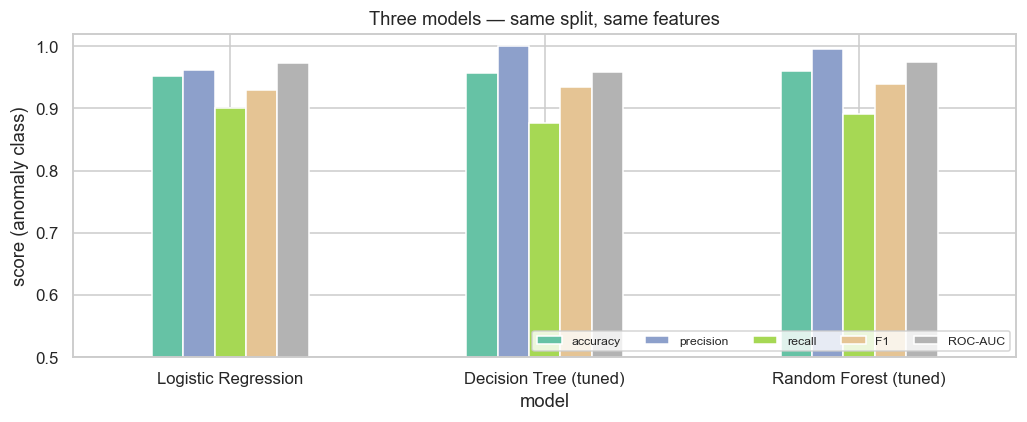

In [26]:
lr_ref = Pipeline([
    ("pre", ColumnTransformer([
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols)])),
    ("lr", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)),
]).fit(X_train, y_train)

dt_ref = GridSearchCV(
    Pipeline([("pre", preprocess), ("dt", DecisionTreeClassifier(random_state=RANDOM_STATE))]),
    {"dt__criterion": ["gini", "entropy"], "dt__max_depth": [3, 4, 5, 6, 8, 10, None],
     "dt__min_samples_leaf": [1, 5, 10], "dt__class_weight": [None, "balanced"]},
    scoring="f1", cv=CV, n_jobs=-1).fit(X_train, y_train).best_estimator_

def row(model, label):
    p = model.predict(X_test); pr = model.predict_proba(X_test)[:, 1]
    return {"model": label,
            "accuracy":  accuracy_score(y_test, p),
            "precision": precision_score(y_test, p),
            "recall":    recall_score(y_test, p),
            "F1":        f1_score(y_test, p),
            "ROC-AUC":   roc_auc_score(y_test, pr),
            "distinct scores": len(np.unique(pr))}

comparison = pd.DataFrame([row(lr_ref, "Logistic Regression"),
                           row(dt_ref, "Decision Tree (tuned)"),
                           row(rf_clf, "Random Forest (tuned)")]).set_index("model")
display(comparison.round(4))

ax = comparison.drop(columns="distinct scores").plot.bar(figsize=(9.5, 4), rot=0, colormap="Set2")
ax.set_ylim(0.5, 1.02); ax.set_ylabel("score (anomaly class)")
ax.set_title("Three models — same split, same features")
ax.legend(loc="lower right", ncol=5, fontsize=8)
plt.tight_layout(); plt.show()

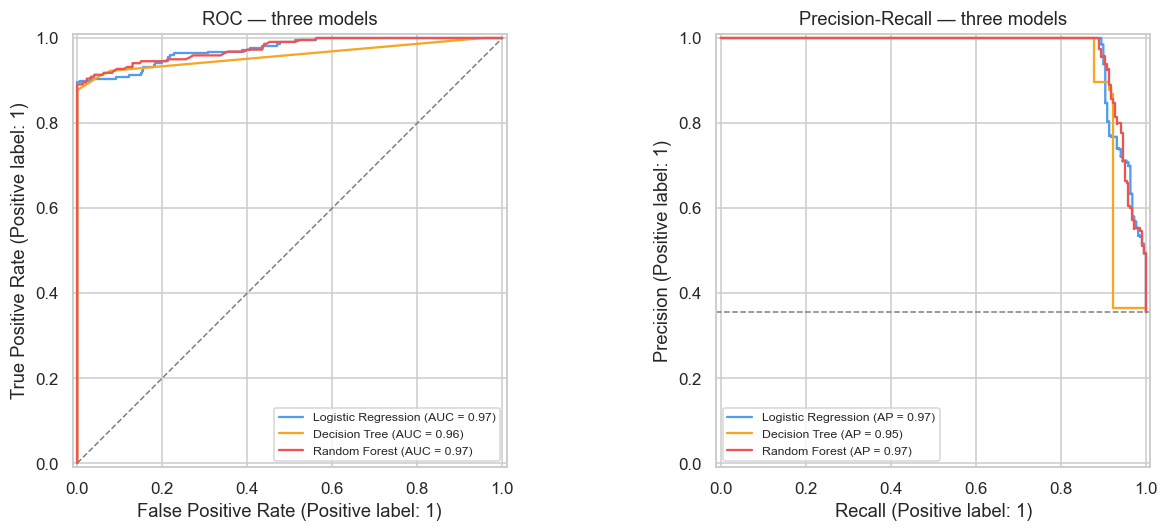

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for model, label, colour in [(lr_ref, "Logistic Regression", "#4f9cf0"),
                             (dt_ref, "Decision Tree", "#f6a623"),
                             (rf_clf, "Random Forest", "#ef5350")]:
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=axes[0], name=label,
                                   curve_kwargs={"color": colour})
    PrecisionRecallDisplay.from_estimator(model, X_test, y_test, ax=axes[1], name=label,
                                          color=colour)
axes[0].plot([0, 1], [0, 1], "--", color="grey", lw=1)
axes[0].set_title("ROC — three models"); axes[0].legend(loc="lower right", fontsize=8)
axes[1].axhline(y_test.mean(), ls="--", color="grey", lw=1)
axes[1].set_title("Precision-Recall — three models"); axes[1].legend(loc="lower left", fontsize=8)
plt.tight_layout(); plt.show()

The `distinct scores` column in the table above is the mechanical explanation for the shape
of those curves. A tree can only emit as many distinct probabilities as it has leaves, so its
ROC curve is a handful of straight segments and its AUC understates how well it separates the
classes — the ranking is low-resolution even where the hard decisions are right. The forest
averages 500 such step functions into a near-continuous score, which is why its curve is
smooth, its AUC rises above its F1, and §6.3's threshold tuning is possible at all.

## 11. Summary

* **Pipeline:** load -> EDA -> clean (drop identifiers, label aliases, constant columns)
  -> one-hot categoricals, **no scaling** -> stratified 80/20 split -> Random Forest tuned by
  5-fold CV on anomaly-class F1, refit at 500 trees. Cleaning and split are identical to the
  Logistic Regression and Decision Tree notebooks, so all three are directly comparable.
* **Why it wins:** §5.1 shows the ensemble beating a single unconstrained tree on held-out
  data with a narrower train-test gap and no pruning — bootstrap averaging cancels the
  variance that made the single tree fragile. §5.3 shows the second ingredient, feature
  subsampling, beating plain bagging (`max_features=None`).
* **Validation for free:** §5.2 uses the out-of-bag rows to estimate generalisation during
  fitting, and confirms the estimate against 5-fold CV. The OOB curve also settles the tree
  count: the error plateaus, so `n_estimators` is a compute decision, not an accuracy one.
* **Usable probabilities:** the vote share over 500 trees is well-resolved, so §6.3 tunes the
  decision threshold to a chosen operating point — a high-recall setting for deployments that
  would rather triage false alarms than miss an intrusion. A single tree cannot do this; §10
  quantifies why (distinct-score count).
* **Interpretability, honestly:** §7 reports impurity importance *and* permutation importance
  on the test set, and reads the disagreement between them. This is the ensemble's real cost:
  it ranks the evidence but cannot hand an analyst the readable rule the Decision Tree
  printed.
* **Realism:** the dataset no longer leaks the label structurally. §8 re-runs the check with
  the model most capable of exploiting a residual shortcut, and §6.2 shows the surviving false
  negatives concentrated in the stealth families the generator deliberately made
  indistinguishable — the floor no model on this data can cross.
* **Limitation:** 500 trees is ~500x the inference cost of the single tree for a modest score
  gain, which matters for on-gateway deployment; and the model is a black box relative to the
  rules of the previous notebook. Where the readable policy is the deliverable, the pruned
  tree is still the better answer.